In [149]:
#Author: Maciej Brzozowski

In [150]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uncertainties import ufloat
from uncertainties.umath import sqrt
from odrpack import odr_fit
from scipy.optimize import curve_fit
from uncertainties import unumpy as unp
%matplotlib inline
plt.ion()

In [151]:
sroba_error=0.01 #mm
waga_error = 0.01 #g

def u_curve_fit(f, xdata,ydata):
    coeffs,cov = curve_fit(f,xdata, unp.nominal_values(ydata), sigma=unp.std_devs(ydata) , absolute_sigma=False)
    return unp.uarray(coeffs,np.sqrt(np.diag(cov)))

def u_odr_fit(f,xdata,ydata,beta0=(0,0)):
    x_std = unp.std_devs(xdata)
    y_std = unp.std_devs(ydata)
    x_std[x_std == 0] = 1e-12
    y_std[y_std == 0] = 1e-12
    weight_x = 1/x_std**2
    weight_y = 1/y_std**2
    
    sol = odr_fit(f, unp.nominal_values(xdata), unp.nominal_values(ydata), beta0,
              weight_x=weight_x, weight_y=weight_y)
    return unp.uarray(sol.beta,sol.sd_beta)
def to_uarray(arr):
    return unp.uarray([x.n for x in arr],[x.s for x in arr])


In [152]:
water_25 = unp.uarray([1.02,1.32,1.62,1.92,2.21,2.51],sroba_error)
water_22 = unp.uarray([0.65,0.98,1.31,1.64,1.97,2.30],sroba_error)
water_20 = unp.uarray([0.87,1.24,1.61,1.99,2.36,2.73],sroba_error)
water_17 = unp.uarray([0.84,1.27,1.70,2.12,2.54,2.97],sroba_error)
X_20 = unp.uarray([0.15,0.55,0.94,1.34,1.73,2.12],sroba_error)
NaCl3_20 = unp.uarray([0.22,0.67,1.11,1.56,2.00,2.44],sroba_error)
NaCl2_20 = unp.uarray([0.11,0.53,0.96,1.38,1.81,2.23],sroba_error)
NaCl1_20 = unp.uarray([0.21,0.61,1.01,1.41,1.81,2.21],sroba_error)

water3mass = ufloat(167.55,waga_error)
salt3mass = ufloat(50.29,waga_error)
procent3= salt3mass/(water3mass+salt3mass)*100
water2mass = ufloat(175.95,waga_error)
salt2mass = ufloat(36.25,waga_error)
procent2= salt2mass/(water2mass+salt2mass)*100
water1mass = ufloat(181.92,waga_error)
salt1mass = ufloat(18.09,waga_error)
procent1= salt1mass/(water1mass+salt1mass)*100

print('{:.2u}'.format(procent1),'{:.2u}'.format(procent2),'{:.2u}'.format(procent3))


def linear_model(x, a, c):
        return a * x + c

9.0445+/-0.0046 17.0829+/-0.0040 23.0858+/-0.0037


In [153]:
def analise_data(Y_data,f=None,unit=None,stezenie = None):
    
    x=np.arange(1,7)
    coeffs = u_curve_fit(linear_model,x, Y_data)
    a,b=coeffs[0],coeffs[1]
    x_fit = np.linspace(min(x), max(x), 100)
    y_fit = a * x_fit + b

    plt.figure()
    plt.plot(x_fit, unp.nominal_values(y_fit))
    plt.scatter(x,unp.nominal_values(Y_data))
    plt.xlabel('Numer pomiaru')
    plt.ylabel(r'Położeniem śruby mikrometrycznej $(mm)$')
    if f is not None:
        plt.title(rf'$f = {f}${unit}')
    if stezenie is not None:
        if stezenie == 'X':
            plt.title('stężenie X')
        else:
            plt.title("stężenie {:.4f}%".format(stezenie.n))
    
    plt.show()
    print('{:.2u}'.format(a),'{:.2u}'.format(b))
    return a,b

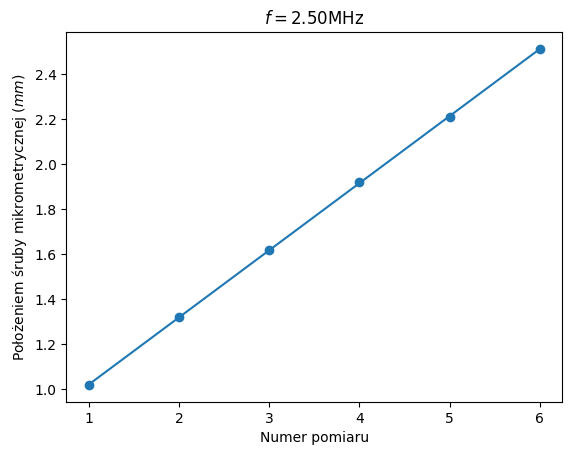

0.29771+/-0.00077 0.7247+/-0.0030


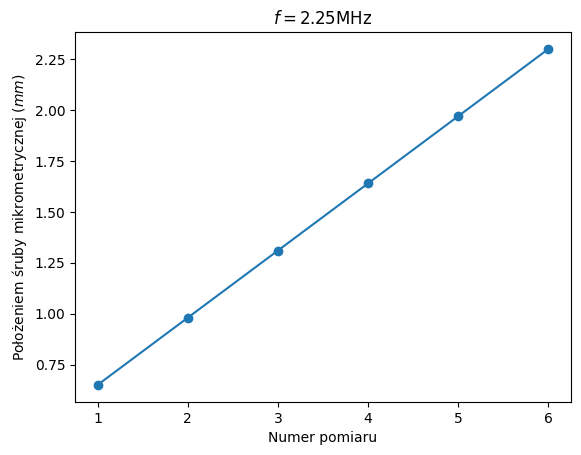

0.329999999999999960+/-0.000000000000000013 0.320000000000000118+/-0.000000000000000052


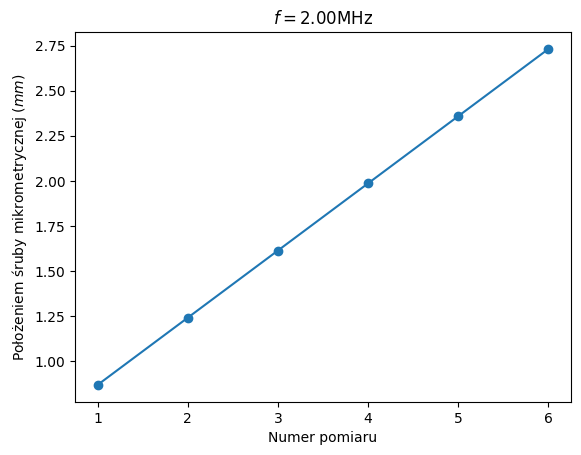

0.37257+/-0.00070 0.4960+/-0.0027


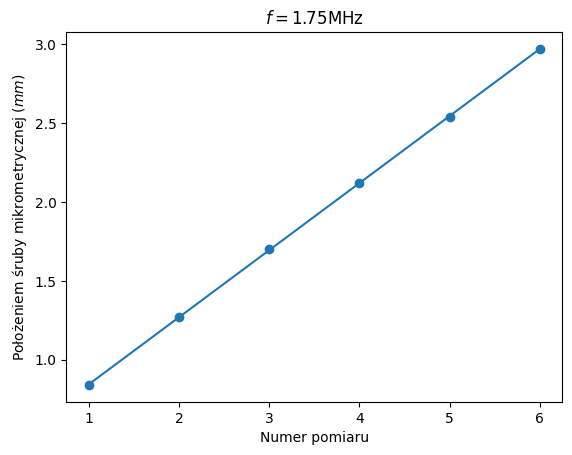

0.4251+/-0.0010 0.4187+/-0.0039


In [154]:
a25,b25 = analise_data(water_25,"2.50","MHz")
a22,b22 = analise_data(water_22,"2.25","MHz")
a20,b20= analise_data(water_20,"2.00","MHz")
a17,b17=analise_data(water_17,"1.75", "MHz")



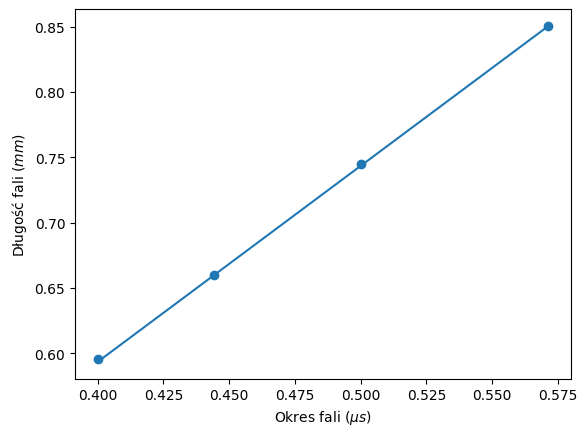

1.50+/-0.04 -0.007+/-0.019


In [155]:
T = np.array([1/1.75,1/2.00,1/2.25,1/2.50])
Y = unp.uarray([a17.n,a20.n,a22.n,a25.n],[a17.s,a20.s,a22.s,a25.s])*2 #dlugosc fali
coeff = u_curve_fit(linear_model,T,Y)
a,b=coeff[0],coeff[1]
x_fit = np.linspace(min(T), max(T), 100)
y_fit = a * x_fit + b
plt.figure()
plt.plot(x_fit, unp.nominal_values(y_fit))
plt.scatter(T,unp.nominal_values(Y))
plt.xlabel(r'Okres fali ($\mu s$)')
plt.ylabel(r'Długość fali ($mm$)')
plt.show()
print(a,b)

/home/maciek/.local/lib/python3.10/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


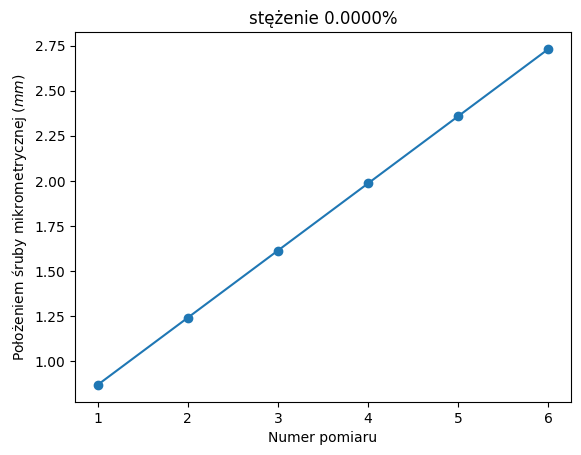

0.37257+/-0.00070 0.4960+/-0.0027


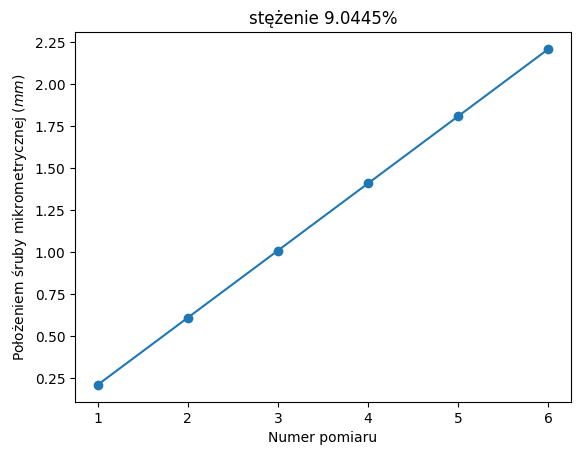

0.400000000000000022+/-0.000000000000000065 -0.19000000000000006+/-0.00000000000000025


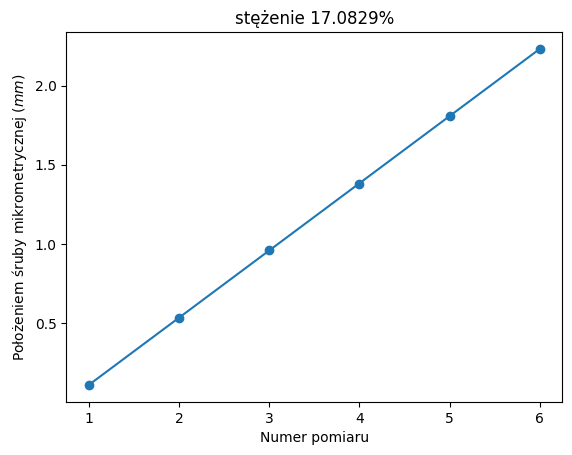

0.42457+/-0.00070 -0.3160+/-0.0027


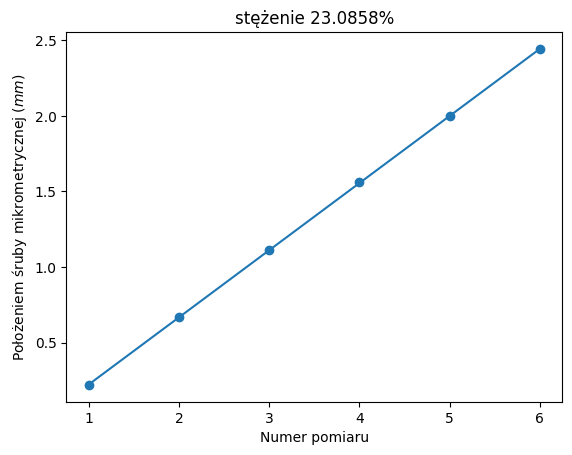

0.44400+/-0.00087 -0.2207+/-0.0034


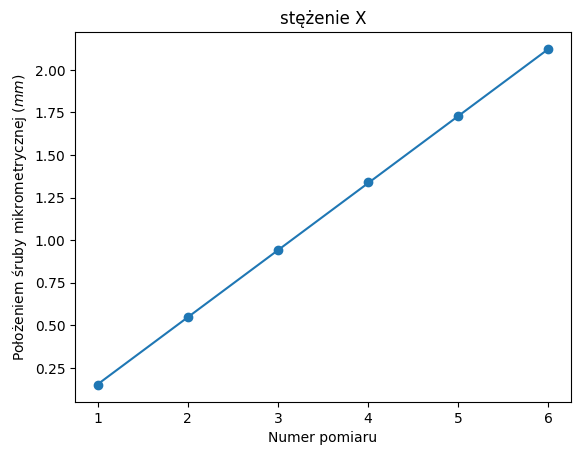

0.39400+/-0.00087 -0.2407+/-0.0034


In [156]:
a0,b0 = analise_data(water_20,stezenie=ufloat(0,0))
a1,b1 = analise_data(NaCl1_20,stezenie=procent1)
a2,b2 = analise_data(NaCl2_20,stezenie=procent2)
a3,b3 = analise_data(NaCl3_20,stezenie=procent3)
aX,bX = analise_data(X_20,stezenie="X")



[1490.2857143573954+/-2.79941682521947 1600.0+/-2.603703995259485e-13
 1698.2857142495855+/-2.7994167710706375
 1775.9999999951485+/-3.4914863057235634]
12.40+/-0.14 1487.8+/-1.2


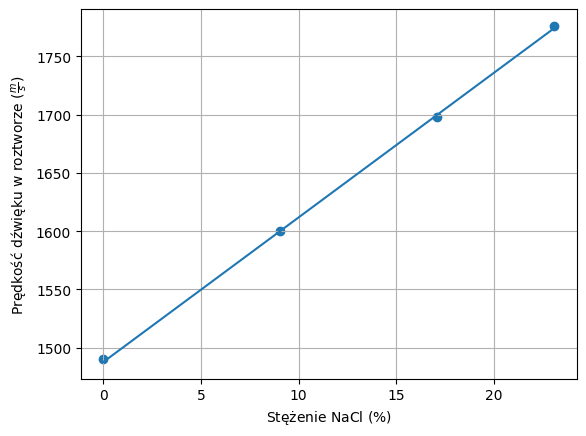

12.40+/-0.14 1487.8+/-1.2


In [157]:
def linear_model(x, beta):
        return beta[0] * x + beta[1]
u = (to_uarray([a0,a1,a2,a3])*2)*2*1000
print(u)
procent = to_uarray([ufloat(0,0),procent1,procent2,procent3])
beta = u_odr_fit(linear_model, procent, u, (0,0))
a,b=beta[0],beta[1]
print(a,b)


x_fit = np.linspace(min(unp.nominal_values(procent)), max(unp.nominal_values(procent)), 100)
y_fit = a * x_fit + b
plt.figure()
plt.plot(x_fit, unp.nominal_values(y_fit))
plt.scatter(unp.nominal_values(procent),unp.nominal_values(u))
plt.xlabel(r'Stężenie NaCl ($\%$)')
plt.ylabel(r'Prędkość dźwięku w roztworze ($\frac{m}{s}$)')
plt.grid()
plt.show()
print(a,b)

1576.0+/-3.5
7.11+/-0.31


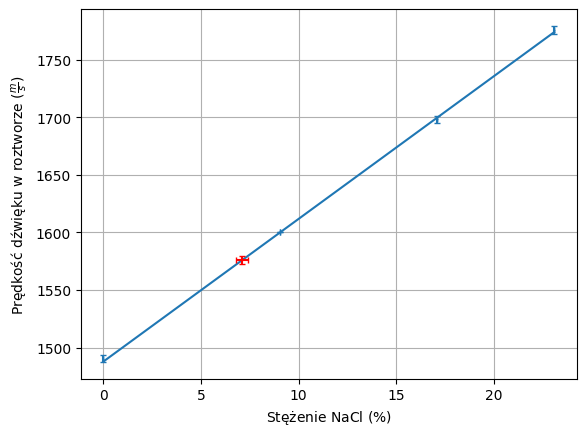

In [166]:
lamX = (aX*2)*2*1000
print(lamX)

procentX = (lamX-b)/a
print(procentX)
plt.figure()
plt.plot(x_fit, unp.nominal_values(y_fit))
plt.scatter(unp.nominal_values(procent),unp.nominal_values(u),s=0.1)
plt.scatter(unp.nominal_values(procentX),unp.nominal_values(lamX),c="red",s=0.1)
plt.errorbar(unp.nominal_values(procent),unp.nominal_values(u),xerr=unp.std_devs(procent),yerr=unp.std_devs(u),fmt="None",capsize=2)
plt.errorbar(unp.nominal_values(procentX),unp.nominal_values(lamX),xerr=unp.std_devs(procentX),yerr=unp.std_devs(lamX),fmt="None",c="red",capsize=2)
plt.xlabel(r'Stężenie NaCl ($\%$)')
plt.ylabel(r'Prędkość dźwięku w roztworze ($\frac{m}{s}$)')
plt.grid()
plt.show()